In [6]:
from function_lib import *

In [7]:
class PairwiseECPERM:
    """
    Pairwise ECP ERM with exponential cone (Optimized).

    Problem:
        min_{B, t, v}  (1/N) * sum_{n} t_n
        s.t.
           ((B^T x_n)^T (z' - z) - t_n,  eta,  v_{n,z,z'}) in K_exp
           sum_{(z,z') in O_n} v_{n,z,z'} <= eta
    """

    def __init__(self, X, C, Z, eta: float, tol: float = 1e-9):
        """
        Parameters
        ----------
        X : array, shape (N, d_x)
        C : array, shape (N, d_c)
        Z : array, shape (K, d_c)
        eta : float
            Exponential cone parameter.
        tol : float
            Tolerance for defining the set O_n.
        """
        self.X = np.asarray(X, dtype=float)
        self.C = np.asarray(C, dtype=float)
        self.Z = np.asarray(Z, dtype=float)
        self.eta = float(eta)
        self.tol = float(tol)

        self.N, self.d_x = self.X.shape
        N_c, self.d_c = self.C.shape
        self.K, d_c2 = self.Z.shape

        if N_c != self.N:
            raise ValueError("X and C must have the same number of rows.")
        if d_c2 != self.d_c:
            raise ValueError("Z dim must match C dim.")

        # 1. Build Data Matrices (Vectorized)
        self._build_O_n_and_linear_operators()

        # 2. Build Mosek Model (Sparse)
        self._build_model()

    def _build_O_n_and_linear_operators(self):
        """
        Vectorized construction of indices and the H matrix.
        """
        X, C, Z = self.X, self.C, self.Z
        tol = self.tol

        # --- 1. Identify all active pairs (n, k, l) ---
        # Compute costs C_n^T z_k for all n, k
        costs = C @ Z.T  # (N, K)

        # Broadcast comparison: costs[n, k] <= costs[n, l] + tol
        # valid_mask[n, k, l] is True if pair (z_k, z_l) is in O_n
        valid_mask = (costs[:, :, None] <= costs[:, None, :] + tol)

        # Extract indices (n, k, l) corresponding to True

        n_indices, k_indices, l_indices = np.where(valid_mask)
        # remove diagonal pairs (z, z)

        mask_offdiag = (k_indices != l_indices)

        n_indices = n_indices[mask_offdiag]
        k_indices = k_indices[mask_offdiag]
        l_indices = l_indices[mask_offdiag]

        Q = len(n_indices)
        self.Q = Q
        
        if Q == 0:
            raise ValueError("No valid pairs found for O_n.")

        # Store n_indices for building sparse matrices later
        self.n_q = n_indices

        # --- 2. Build H matrix (Vectorized) ---
        # H[q] = vec( x_n outer (z_l - z_k) )
        # We construct this directly using broadcasting without loops.

        X_sel = X[n_indices]               # Shape (Q, d_x)
        Z_diff = Z[k_indices] - Z[l_indices] # Shape (Q, d_c)

        # Outer product: (Q, d_x, 1) * (Q, 1, d_c) -> (Q, d_x, d_c)
        H_tensor = X_sel[:, :, None] * Z_diff[:, None, :]
        
        # Flatten to (Q, d_x * d_c)
        self.H = H_tensor.reshape(Q, -1)

    def _build_model(self):
        """
        Builds the MOSEK optimization model using sparse mapping matrices.
        """
        self.M = Model("pairwise_ecp_erm_fast")
        M = self.M

        N, d_x, d_c, Q = self.N, self.d_x, self.d_c, self.Q

        # --- Variables ---
        self.B = M.variable("B", [d_x, d_c], Domain.unbounded())
        self.t = M.variable("t", N, Domain.unbounded())
        self.v = M.variable("v", Q, Domain.unbounded())

        # --- Linear Terms ---

        # 1. Term H * vec(B)
        # H is dense (Q x dx*dc), but usually reasonable size compared to Tmap
        B_flat = Expr.reshape(self.B, d_x * d_c)
        H_mat = Matrix.dense(self.H)
        HB = Expr.mul(H_mat, B_flat)

        # 2. Term t_{n_q} using Sparse Matrix
        # FIX: Explicitly use int32 arrays for indices
        row_indices = np.arange(Q, dtype=np.int32)
        col_indices = self.n_q.astype(np.int32)
        vals = np.ones(Q, dtype=float)

        # Matrix.sparse(num_rows, num_cols, row_idx, col_idx, values)
        Tmap_mat = Matrix.sparse(Q, N, row_indices, col_indices, vals)
        Tt = Expr.mul(Tmap_mat, self.t)

        # u_q = (H B)_q - t_{n_q}
        U = Expr.sub(HB, Tt)

        # --- Constraints ---

        # 1. Exponential Cone: ((u), eta, v) \in K_exp
        U_col = Expr.reshape(U, [Q, 1])
        v_col = Expr.reshape(self.v, [Q, 1])
        
        eta_vec = np.full((Q, 1), self.eta, dtype=float)
        eta_mat = Matrix.dense(eta_vec)
        eta_expr = Expr.constTerm(eta_mat)

        exp_triplets = Expr.hstack(v_col, eta_expr, U_col)
        M.constraint("exp_cones", exp_triplets, Domain.inPExpCone())

        # 2. Sum Constraint: sum_{q in O_n} v_q <= eta
        # We equivalent to Tmap^T * v <= eta
        # FIX: Same int32 casting for the transpose matrix indices
        # Rows of Transpose = Cols of Original (n_q)
        # Cols of Transpose = Rows of Original (0..Q-1)
        Tmap_T_mat = Matrix.sparse(N, Q, col_indices, row_indices, vals)
        sum_v = Expr.mul(Tmap_T_mat, self.v)

        M.constraint("sum_v_le_eta", sum_v, Domain.lessThan(np.full(N, self.eta)))

        # --- Objective ---
        # min (1/N) * sum(t)

        t_sum = Expr.sum(self.t)               # scalar
        obj = Expr.mul(1.0 / N, t_sum)
        M.objective("obj", ObjectiveSense.Minimize, obj)

    def solve(self, verbose: bool = False):
        """
        Solves the model. Returns dictionary of results.
        """
        if verbose:
            self.M.setLogHandler(sys.stdout)
        else:
            self.M.setLogHandler(None)

        self.M.solve()

        status = self.M.getPrimalSolutionStatus()
        if status != SolutionStatus.Optimal:
            # You might want to handle NearOptimal or distinct cases
            if verbose:
                print(f"Warning: Optimization finished with status {status}")

        B_val = np.array(self.B.level()).reshape(self.d_x, self.d_c)
        t_val = np.array(self.t.level())
        # v_val = np.array(self.v.level()) # Often very large, commented out to save return memory
        obj_val = self.M.primalObjValue()

        return {
            "B": B_val,
            "t": t_val,
            "obj": obj_val
        }

    def evaluate_regret(self, X_test, C_test, B=None, return_per_sample=False):
        """
        Vectorized regret evaluation.
        """
        X_test = np.asarray(X_test, dtype=float)
        C_test = np.asarray(C_test, dtype=float)
        N_test = X_test.shape[0]

        if B is None:
            B = np.array(self.B.level()).reshape(self.d_x, self.d_c)
        else:
            B = np.asarray(B, dtype=float).reshape(self.d_x, self.d_c)

        # 1. Predict costs: C_hat = X * B
        C_hat = X_test @ B 

        # 2. Evaluate all z options against predicted costs
        # obj_pred[n, k] = c_hat_n^T z_k
        obj_pred = C_hat @ self.Z.T 

        # 3. Find predicted best decision index
        idx_hat = np.argmin(obj_pred, axis=1)

        # 4. Evaluate actual costs
        obj_true = C_test @ self.Z.T

        # 5. Calculate Regret
        # Cost of chosen decision - Cost of optimal decision (using true C)
        chosen_costs = obj_true[np.arange(N_test), idx_hat]
        optimal_costs = obj_true.min(axis=1)

        # regrets = chosen_costs - optimal_costs
        regrets = (chosen_costs - optimal_costs)/optimal_costs
        avg_regret = float(regrets.mean())

        result = {"avg_regret": avg_regret}
        if return_per_sample:
            result["regret_per_sample"] = regrets

        return result

In [8]:
# ----------------- config -----------------
n_instance   = 100
input_dim    = 3
noise        = 0.5
deg          = 2
grid_width   = 3
n_simulation = 30

# ----------------- paths ------------------
base_path = change_to_py_file_dir()
base      = os.path.join(base_path, "Data", "Shortest_path")

# ----------------- results ----------------
total_result  = {}
# =========================================================
# main loop over seeds
# =========================================================

# ----- build Z (all feasible z) only once -----
sols, edges, G = generate_all_feasible_solutions(grid_width=grid_width)

model_list = ["PAR-0.1", "PAR-1", "PAR-10", "PAR-100", "PAR-1000", "PAR-10000", "PAR-100000", "PAR-1000000"]
for model_type in model_list:
    regret_result = []
    parame_result = []

    if model_type.startswith("PAR-"):
        eta = float(model_type.split("-")[1])
    else:
        raise ValueError(f"Unknown model type: {model_type}")
    
    for seed in tqdm(range(n_simulation),
                     desc=f"Running simulations ({model_type})",
                     colour="green"):

        # ---- reproducibility ----
        random.seed(seed)
        np.random.seed(seed)

        # ---- data for this seed ----
        x_train, y_train, x_test, y_test = load_shortest_path_setting_with_splits(
            base, n_instance, input_dim, deg, noise, grid_width, seed
        )

        # ---- build solver for THIS (X, C) ----
        # must rebuild because O_n depends on y_train (C)
        solver = PairwiseECPERM(
            X=x_train,
            C=y_train,
            Z=sols,
            eta=eta,
            tol=1e-9
        )

        # ---- solve training problem for this seed ----
        res = solver.solve(verbose=False)

        # ---- evaluate regret on test set ----
        eval_res = solver.evaluate_regret(
            x_test, y_test, return_per_sample=False
        )

        regret_result.append(eval_res["avg_regret"])
        parame_result.append(res["B"])
        # print(f"Seed {seed}: Avg Regret = {eval_res['avg_regret']:.4f}")

        # ---- if a previous solver exists, destroy it ----
        if solver is not None:
            solver.M.dispose()   # release MOSEK memory
            del solver
        gc.collect()         # force Python GC to clean handles

    # save results for this model type
    total_result[model_type] = {
        "regret": regret_result,
        "params": parame_result
    }

    process = psutil.Process(os.getpid())
    print(f"Python process RAM: {process.memory_info().rss/1024/1024/1024:.3f} GB")

# Save the result to pickle file
save_path = os.path.join(base_path, "Results", "Score")
os.makedirs(save_path, exist_ok=True)   # create directory if not exist
file_path = os.path.join(save_path, f"Shortest_path_pair_result_{n_instance}_{input_dim}_{deg}_{noise}_{grid_width}.pkl")
with open(file_path, "wb") as f:
    pickle.dump(total_result, f)

def print_memory():
    mem = psutil.virtual_memory()
    print(f"Available: {mem.available/1024/1024/1024:.2f} GB")
    print(f"Used:      {(mem.total - mem.available)/1024/1024/1024:.2f} GB")
    print(f"Percent:   {mem.percent}%")

print_memory()

Running simulations (PAR-0.1): 100%|██████████| 30/30 [00:02<00:00, 10.98it/s]


Python process RAM: 0.212 GB


Running simulations (PAR-1): 100%|██████████| 30/30 [00:03<00:00,  9.34it/s]


Python process RAM: 0.213 GB


Running simulations (PAR-10): 100%|██████████| 30/30 [00:03<00:00,  8.43it/s]


...

Python process RAM: 0.208 GB


Running simulations (PAR-100000): 100%|██████████| 30/30 [00:02<00:00, 10.22it/s]


Python process RAM: 0.209 GB


Running simulations (PAR-1000000): 100%|██████████| 30/30 [00:02<00:00, 10.10it/s]

Python process RAM: 0.209 GB
Available: 17.30 GB
Used:      14.45 GB
Percent:   45.5%


C:\Users\zhaoz\AppData\Local\Temp\ipykernel_23576\2430784666.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


      Model     Mean      Std    VaR90   CVaR90
    PAR-0.1 0.097783 0.049757 0.163922 0.204428
      PAR-1 0.097783 0.049757 0.163922 0.204428
     PAR-10 0.097783 0.049757 0.163922 0.204428
    PAR-100 0.097783 0.049757 0.163922 0.204428
   PAR-1000 0.097783 0.049757 0.163922 0.204428
  PAR-10000 0.097783 0.049757 0.163922 0.204428
 PAR-100000 0.097783 0.049757 0.163922 0.204428
PAR-1000000 0.097783 0.049757 0.163922 0.204428


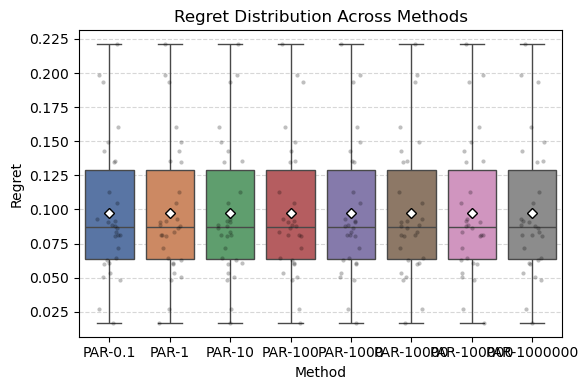

In [ ]:
# Compute stats for the LST model
# regrets = total_result["LST-0.1"]["regret"]

# mean, std, var90, cvar90 = compute_stats(regrets)

# print(f"Mean    : {mean:.6f}")
# print(f"Std     : {std:.6f}")
# print(f"VaR 90  : {var90:.6f}")
# print(f"CVaR 90 : {cvar90:.6f}")
rows = []
for model_type in model_list:
    regrets = total_result[model_type]["regret"]
    mean, std, var90, cvar90 = compute_stats(regrets)

    rows.append({
        "Model": model_type,
        "Mean": mean,
        "Std": std,
        "VaR90": var90,
        "CVaR90": cvar90
    })

# convert to DataFrame
df = pd.DataFrame(rows)

# nicely formatted print
print(df.to_string(index=False, float_format="%.6f"))


# Collect regret distributions across all model types
df_list = []
for model_type, data in total_result.items():
    df_list.append(pd.DataFrame({
        "method": [model_type] * len(data["regret"]),
        "regret": data["regret"]
    }))

df = pd.concat(df_list, ignore_index=True)

# Academic color palette
palette = sns.color_palette("deep")
unique_methods = sorted(df["method"].unique())
method_colors = {m: palette[i % len(palette)] for i, m in enumerate(unique_methods)}

plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="method",
    y="regret",
    palette=method_colors,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 5
    }
)

sns.stripplot(
    data=df,
    x="method",
    y="regret",
    color="black",
    alpha=0.25,
    jitter=0.2,
    size=3
)

plt.title("Regret Distribution Across Methods", fontsize=12)
plt.ylabel("Regret")
plt.xlabel("Method")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

# Save figure
save_dir = os.path.join(base_path, "Results", "Figures")
os.makedirs(save_dir, exist_ok=True)

plt.savefig(
    os.path.join(save_dir, "pair_regret_comparison.png"),
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [10]:
# seed = 1
# x_train, y_train, x_test, y_test = load_shortest_path_setting_with_splits(base, n_instance, input_dim, deg, noise, grid_width, seed)

# # Example usage:

# sols, edges, G = generate_all_feasible_solutions(grid_width=5)
# print("Number of edges:", len(edges))
# print("Number of feasible s->t paths:", len(sols))
# print("First solution vector:", sols[0])

# # pick any solution
# vec = sols[10]
# # draw
# draw_solution(G, edges, vec, grid_width=5, cost=y_train[0])
# solver = LSTECPParam(
#     N=x_train.shape[0],
#     d_x=x_train.shape[1],
#     d_c=y_train.shape[1],
#     Z=sols,
#     eta=0.5
# )

# X_run = x_train   # shape (N, d_x)
# C_run = y_train   # shape (N, d_c)

# res = solver.solve(X_run, C_run, verbose=False)
# eval_res = solver.evaluate_regret(x_test, y_test, return_per_sample=True)
# print("Avg regret:", eval_res["avg_regret"])
# # print("Per-sample regret:", eval_res["regret_per_sample"])
